# Previous Violation History Figure


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2


prev_viol_exp = "2025_07_19_fig3_fit_prev_violation_rs47.pkl"
filt_prev_viol_exp = "2025_07_19_fig3_fit_filt_prev_violation_rs47.pkl"
tau_sweep_exp = "2025_07_19_fig3_sweep_prev_viol_taus_rs47.pkl"
compare_exp = "2025_07_19_fig3_compare_prev_viol_rs47.pkl"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
df = DatasetLoader().load_data()

DataLoader: Loading data type:  new_trained_cleaned  for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [14]:

# --- Function Definitions ---

def compute_autocorrelation(x, max_lag):
    """
    Compute the autocorrelation for lags in [-max_lag, ..., max_lag]
    and normalize by the variance (lag 0 value).
    """
    x_centered = x - np.mean(x)
    result = np.correlate(x_centered, x_centered, mode='full')
    mid = len(result) // 2  # lag zero index
    ac_slice = result[mid - max_lag: mid + max_lag + 1]
    denom = ac_slice[max_lag] if ac_slice[max_lag] != 0 else 1
    return ac_slice / denom

def compute_all_autocorrelograms(df, max_lag=30):
    """
    Compute the autocorrelogram for each animal-session.
    Excludes groups that have too few trials or with no violations.
    """
    ac_list = []
    for sess, group in df.groupby('animal_id_session'):
        # Sort by trial number to maintain time order.
        series = group.sort_values('trial')['violation'].values
        if len(series) <= max_lag or not np.any(series):
            continue  # skip sessions with too few trials or with all zeros
        ac = compute_autocorrelation(series, max_lag)
        ac_list.append(ac)
    return np.array(ac_list)

def bootstrap_ci(ac_array, n_boot=1000, ci=95):
    """
    Compute bootstrap confidence intervals across sessions.
    """
    bootstraps = []
    for _ in range(n_boot):
        sample = ac_array[np.random.choice(len(ac_array), len(ac_array), replace=True)]
        bootstraps.append(np.mean(sample, axis=0))
    bootstraps = np.array(bootstraps)
    lower = np.percentile(bootstraps, (100 - ci) / 2, axis=0)
    upper = np.percentile(bootstraps, 100 - (100 - ci) / 2, axis=0)
    return lower, upper

def shuffled_null_distribution(df, max_lag=30, n_shuffles=500):
    """
    Generate a null (shuffle) distribution of autocorrelograms.
    For each shuffle, randomly permute 'violation' values within each animal-session.
    Returns the mean and the 2.5/97.5 percentile bounds (null intervals).
    """
    nulls = []
    for _ in tqdm(range(n_shuffles), desc="Shuffling"):
        df_shuffled = df.copy()
        # Shuffle the 'violation' column within each animal-session group.
        df_shuffled['violation'] = df_shuffled.groupby('animal_id_session')['violation'] \
                                             .transform(np.random.permutation)
        ac_shuffled = compute_all_autocorrelograms(df_shuffled, max_lag=max_lag)
        if len(ac_shuffled) > 0:
            nulls.append(np.mean(ac_shuffled, axis=0))
    nulls = np.array(nulls)
    mean_null = np.mean(nulls, axis=0)
    lower = np.percentile(nulls, 2.5, axis=0)
    upper = np.percentile(nulls, 97.5, axis=0)
    return mean_null, lower, upper

def get_p_values(obs_mean_ac, null_dist):
    """
    Compute a two-tailed p-value at each lag:
        p = fraction of null autocorrelation values (absolute)
            exceeding the absolute observed mean autocorrelation.
    """
    pvals = []
    # Loop over each lag index in the autocorrelation vector.
    for i in range(obs_mean_ac.shape[0]):
        obs_val = obs_mean_ac[i]
        null_vals = null_dist[:, i]
        # Count null values at least as extreme (absolute) as the observed value.
        count_extreme = np.sum(np.abs(null_vals) >= np.abs(obs_val))
        p = count_extreme / len(null_vals)
        pvals.append(p)
    return np.array(pvals)


In [15]:
# Set parameters.
max_lag = 20
n_shuffles = 100

# 1. Compute observed autocorrelograms.
ac_array = compute_all_autocorrelograms(df, max_lag=max_lag)
if ac_array.shape[0] == 0:
    raise ValueError("No valid sessions found with enough trials and at least one violation.")
obs_mean_ac = np.mean(ac_array, axis=0)

# 2. Compute bootstrap confidence intervals for the observed autocorrelations.
ci_lower, ci_upper = bootstrap_ci(ac_array, n_boot=1000, ci=95)

# 3. Generate the shuffled (null) distribution.
null_mean, null_lower, null_upper = shuffled_null_distribution(df, max_lag=max_lag, n_shuffles=n_shuffles)

# 4. Define lags.
lags = np.arange(-max_lag, max_lag+1)


Shuffling: 100%|██████████| 100/100 [02:29<00:00,  1.50s/it]


In [16]:
# Create a dictionary with all the computed statistics
violation_stats = {
    'observed_mean': obs_mean_ac,
    'confidence_intervals': {
        'lower': ci_lower,
        'upper': ci_upper
    },
    'null_distribution': {
        'mean': null_mean,
        'lower': null_lower,
        'upper': null_upper
    },
    'lags': lags,
    'parameters': {
        'max_lag': max_lag,
        'n_shuffles': n_shuffles
    }
}

# Save the dictionary using pickle
import pickle
with open(c.DATA_PATH + 'fig3_violation_autocorrelation_stats.pkl', 'wb') as f:
    pickle.dump(violation_stats, f)


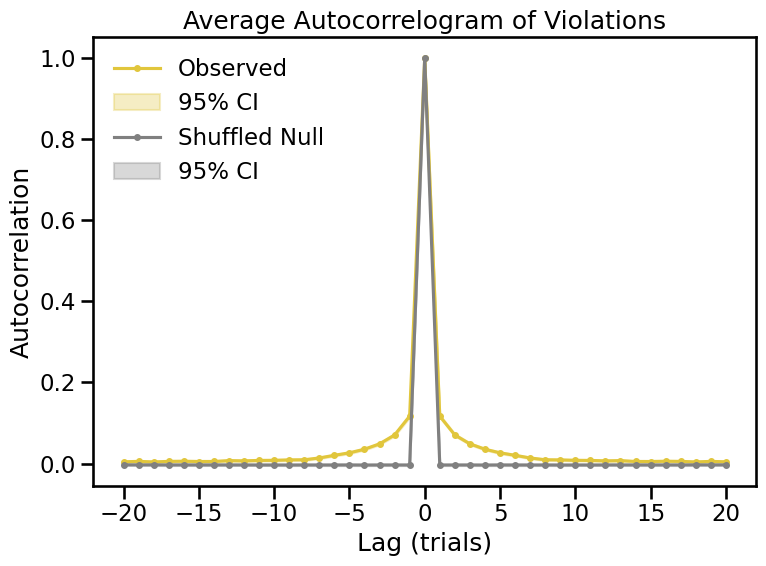

In [17]:

fig, ax = plt.subplots(figsize=(8, 6))

# Plot observed autocorrelation.
plt.plot(lags, obs_mean_ac, label='Observed', color=c.VIOLATION_COLOR, marker="o", markersize=4)
plt.fill_between(lags, ci_lower, ci_upper, alpha=0.3, color=c.VIOLATION_COLOR, label='95% CI')

# Plot the shuffled (null) distribution.
plt.plot(lags, null_mean, label='Shuffled Null', color='gray', marker="o", markersize=4)
plt.fill_between(lags, null_lower, null_upper, alpha=0.3, color='gray', label='95% CI')
# Decoration.
# plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
# ax.set_xlim(-15,15)
plt.title('Average Autocorrelogram of Violations')
plt.legend(frameon=False, loc = "upper left")
plt.tight_layout()


In [18]:

# 6. (Optional) Compute p-values for each lag.
# Here we re-run the shuffling process to store each shuffle's mean autocorrelogram.
null_distribution = []
for _ in tqdm(range(n_shuffles), desc="Computing p-values via shuffles"):
    df_shuffled = df.copy()
    df_shuffled['violation'] = df_shuffled.groupby('animal_id_session')['violation'] \
                                         .transform(np.random.permutation)
    ac_shuffled = compute_all_autocorrelograms(df_shuffled, max_lag=max_lag)
    if len(ac_shuffled) > 0:
        null_distribution.append(np.mean(ac_shuffled, axis=0))
null_distribution = np.array(null_distribution)
p_values = get_p_values(obs_mean_ac, null_distribution)
print("p-values at each lag:")
for lag, p in zip(lags, p_values):
    print(f"Lag {lag}: p = {p:.3f}")


Computing p-values via shuffles:   2%|▏         | 2/100 [00:03<02:40,  1.64s/it]

Computing p-values via shuffles: 100%|██████████| 100/100 [02:29<00:00,  1.49s/it]

p-values at each lag:
Lag -20: p = 0.040
Lag -19: p = 0.000
Lag -18: p = 0.010
Lag -17: p = 0.000
Lag -16: p = 0.000
Lag -15: p = 0.000
Lag -14: p = 0.000
Lag -13: p = 0.000
Lag -12: p = 0.000
Lag -11: p = 0.000
Lag -10: p = 0.000
Lag -9: p = 0.000
Lag -8: p = 0.000
Lag -7: p = 0.000
Lag -6: p = 0.000
Lag -5: p = 0.000
Lag -4: p = 0.000
Lag -3: p = 0.000
Lag -2: p = 0.000
Lag -1: p = 0.000
Lag 0: p = 1.000
Lag 1: p = 0.000
Lag 2: p = 0.000
Lag 3: p = 0.000
Lag 4: p = 0.000
Lag 5: p = 0.000
Lag 6: p = 0.000
Lag 7: p = 0.000
Lag 8: p = 0.000
Lag 9: p = 0.000
Lag 10: p = 0.000
Lag 11: p = 0.000
Lag 12: p = 0.000
Lag 13: p = 0.000
Lag 14: p = 0.000
Lag 15: p = 0.000
Lag 16: p = 0.000
Lag 17: p = 0.000
Lag 18: p = 0.010
Lag 19: p = 0.000
Lag 20: p = 0.040


In [19]:
# Optionally, if you want to control for multiple comparisons across lags,
# you may apply a correction, such as Bonferroni or FDR, to these p-values.
# For instance, for Bonferroni:
corrected_p = np.minimum(p_values * len(p_values), 1.0)
print("Bonferroni-corrected p-values at each lag:")
for lag, p in zip(lags, corrected_p):
    print(f"Lag {lag}: corrected p = {p:.3f}")

Bonferroni-corrected p-values at each lag:
Lag -20: corrected p = 1.000
Lag -19: corrected p = 0.000
Lag -18: corrected p = 0.410
Lag -17: corrected p = 0.000
Lag -16: corrected p = 0.000
Lag -15: corrected p = 0.000
Lag -14: corrected p = 0.000
Lag -13: corrected p = 0.000
Lag -12: corrected p = 0.000
Lag -11: corrected p = 0.000
Lag -10: corrected p = 0.000
Lag -9: corrected p = 0.000
Lag -8: corrected p = 0.000
Lag -7: corrected p = 0.000
Lag -6: corrected p = 0.000
Lag -5: corrected p = 0.000
Lag -4: corrected p = 0.000
Lag -3: corrected p = 0.000
Lag -2: corrected p = 0.000
Lag -1: corrected p = 0.000
Lag 0: corrected p = 1.000
Lag 1: corrected p = 0.000
Lag 2: corrected p = 0.000
Lag 3: corrected p = 0.000
Lag 4: corrected p = 0.000
Lag 5: corrected p = 0.000
Lag 6: corrected p = 0.000
Lag 7: corrected p = 0.000
Lag 8: corrected p = 0.000
Lag 9: corrected p = 0.000
Lag 10: corrected p = 0.000
Lag 11: corrected p = 0.000
Lag 12: corrected p = 0.000
Lag 13: corrected p = 0.000
Lag 

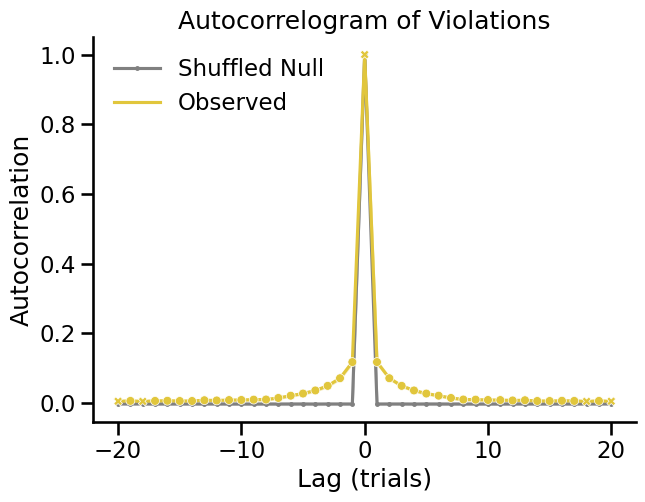

In [20]:
# Assume lags, obs_mean_ac, and corrected_p are already defined.
# Create a significance column based on your alpha threshold.
alpha = 0.05
df_obs = pd.DataFrame({
    'lags': lags,
    'obs_mean_ac': obs_mean_ac,
    'Significance': np.where(corrected_p < alpha, 'Significant', 'Non-significant')
})

fig, ax = plt.subplots(figsize=(7, 5))
# Plot the shuffled (null) distribution.
plt.plot(lags, null_mean, label='Shuffled Null', color='gray', marker='.', markersize=5)
plt.fill_between(lags, null_lower, null_upper, alpha=0.3, color='gray')

# Plot the continuous line for observed autocorrelation.
sns.lineplot(data=df_obs, x="lags", y="obs_mean_ac", ax=ax,
             color=c.VIOLATION_COLOR, linestyle='-', label="Observed")

# Overlay markers with size mapped to significance.
# Here, we use sizes to indicate significance: larger for significant points.
sns.scatterplot(data=df_obs, x="lags", y="obs_mean_ac", hue="Significance",
                palette={'Significant': c.VIOLATION_COLOR, 'Non-significant': c.VIOLATION_COLOR},
                style="Significance",
                markers={'Significant': 'o', 'Non-significant': 'X'},
                legend=False, ax=ax, zorder=10, size=20)

plt.fill_between(lags, ci_lower, ci_upper, alpha=0.3, color=c.VIOLATION_COLOR)



plt.title('Average Autocorrelogram of Violations')
plt.legend(frameon=False, loc = "upper left")
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelogram of Violations')
sns.despine()

plt.savefig("figures/fig3_violation_autocorrelogram", dpi=300, bbox_inches="tight")



# B- Prev Viol Weights


In [21]:
ddf = pd.DataFrame()

ddf["trial"] = np.arange(1,11)
ddf["violation"] = [0,1,0,0,0,0,1,0,0,0]
ddf["prev_violation"] = [0,0,1,0,0,0,0,1,0,0]

filter = ExpFilter(tau=4)
filter.apply_filter_to_session("prev_violation", ddf)
max_val = ddf["prev_violation_exp"].max()
ddf["prev_violation_exp_tau4"] = ddf["prev_violation_exp"] / (max_val + 0.12)

filter = ExpFilter(tau=1)
filter.apply_filter_to_session("prev_violation", ddf)
max_val = ddf["prev_violation_exp"].max()
ddf["prev_violation_exp_tau1"] = ddf["prev_violation_exp"] / (max_val + 0.12)

ddf.drop(columns=["prev_violation_exp"], inplace=True)

ex_data = df.query("animal_id == 'W072'").copy()
ddf["s_a"] = standardize(ex_data.s_a).values[:len(ddf)]
ddf["s_b"] = standardize(ex_data.s_b).values[:len(ddf)]
ddf["s_a_x_prev_violation"] = ddf["s_a"] * ddf["prev_violation"]

ddf.to_csv(c.DATA_PATH + "demo_intuition_data.csv", index=False)

ddf

,trial,violation,prev_violation,prev_violation_exp_tau4,prev_violation_exp_tau1,s_a,s_b,s_a_x_prev_violation
0,1,0,0,0.000000,0.000000,-1.586190,-0.588785,-0.000000
1,2,1,0,0.000000,0.000000,-0.749555,0.172252,-0.000000
2,3,0,1,0.710982,0.892857,-1.586190,-0.588785,-1.586190
3,4,0,0,0.553714,0.328464,-0.749555,-1.349822,-0.000000
4,5,0,0,0.431233,0.120835,0.087079,-0.588785,0.000000
5,6,0,0,0.335844,0.044453,0.923713,1.694326,0.000000
6,7,1,0,0.261556,0.016353,0.087079,0.933289,0.000000
7,8,0,1,0.914682,0.892857,0.923713,1.694326,0.923713
8,9,0,0,0.712355,0.328464,0.923713,1.694326,0.000000
9,10,0,0,0.554783,0.120835,1.760348,0.933289,0.000000


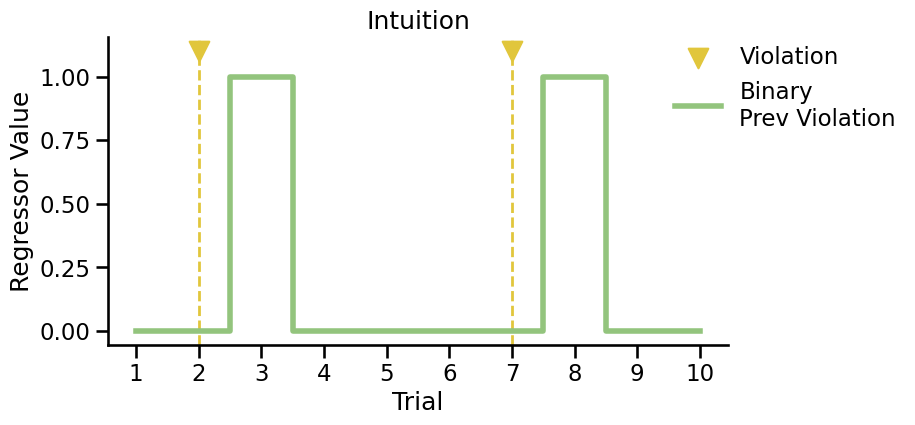

In [22]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4)

ax.legend(bbox_to_anchor=(.90, 1), borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Intuition",
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig3_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

In [25]:
mvpv = ModelVisualizer(load_experiment(prev_viol_exp, save_path=c.MODEL_FITS_PATH))
XMIN=-2.1
XMAX=2.1

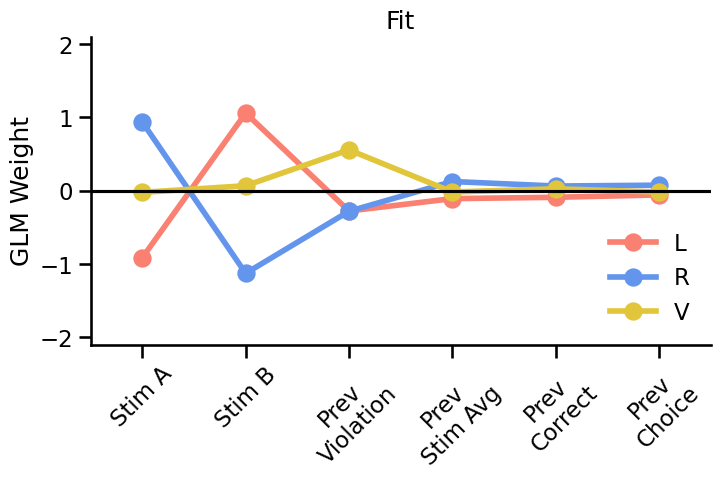

In [26]:
fig, ax = plt.subplots(figsize=(8, 4)) 

mvpv.plot_weights_summary(ax=ax,style="point", plot_bias = False, title="Fit", plot_individuals=False, seed=19, palette=c.MULTI_CHOICE_PAL,errorbar="se")

ax.legend(loc="lower right", frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Prev\nViolation", 
    "Prev\nStim Avg", 
    "Prev\nCorrect", 
    "Prev\nChoice"
]

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS)

ax.set_ylim(XMIN, XMAX)

plt.savefig("figures/fig3_prev_viol_weights.png", dpi=300, bbox_inches="tight")



# C/D Filt Prev Viol Weights & Tau


In [27]:
mvfpv = ModelVisualizer(load_experiment(filt_prev_viol_exp, save_path=c.MODEL_FITS_PATH))


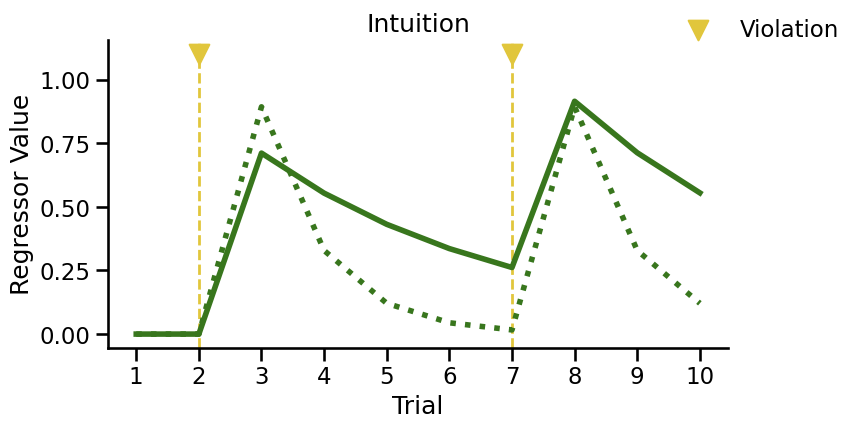

In [28]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation_exp_tau4"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation_exp_tau1"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, linestyle=":")

ax.legend(bbox_to_anchor=(.9, 1.1), borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Intuition"
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()
plt.savefig("figures/fig3_filt_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

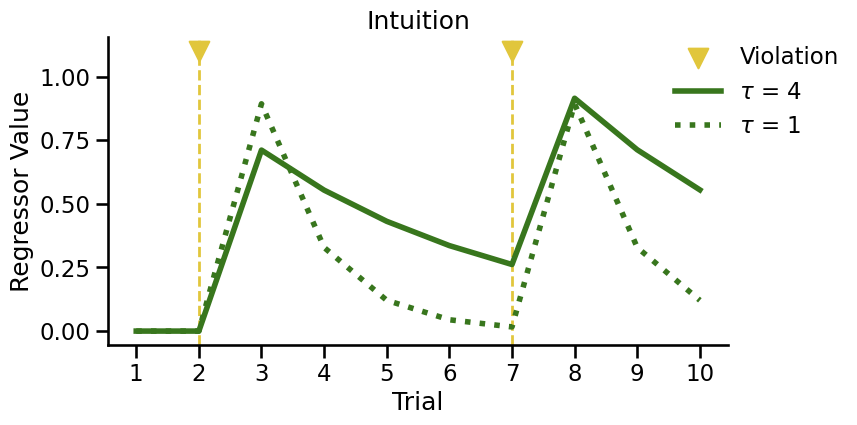

In [27]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation_exp_tau4"], ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, label=r"$\tau$ = 4")

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation_exp_tau1"], label=r"$\tau$ = 1", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, linestyle=":")

ax.legend(bbox_to_anchor=(.9, 1), borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Intuition"
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()
plt.savefig("figures/fig3_filt_prev_viol_weights_intuition_labels.png", dpi=300, bbox_inches="tight")

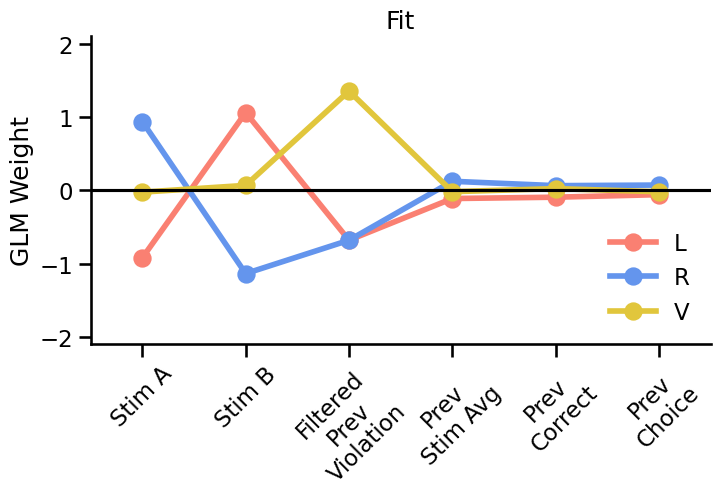

In [28]:
fig, ax = plt.subplots(figsize=(8, 4)) 

mvfpv.plot_weights_summary(ax=ax,style="point", plot_bias = False, title="Fit", plot_individuals=False, seed=19, palette=c.MULTI_CHOICE_PAL,errorbar=None)

ax.legend(loc="lower right", frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Filtered\nPrev\nViolation", 
    "Prev\nStim Avg", 
    "Prev\nCorrect", 
    "Prev\nChoice"
]

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS)

ax.set_ylim(XMIN, XMAX)

plt.savefig("figures/fig3_filt_prev_viol_weights.png", dpi=300, bbox_inches="tight")



## Taus


In [29]:
tau_sweep_exp_load = load_experiment(tau_sweep_exp, save_path=c.MODEL_FITS_PATH)
mvt = ModelVisualizerTauSweep(tau_sweep_exp_load)

In [30]:
best_fit_df = mvt.find_best_fit(group="animal_id")[["animal_id", "tau"]].copy()
best_fit_df.rename(columns={"tau": "best_fit_tau"}, inplace=True)
taus_df =mvt.find_best_fit(group="tau")[["animal_id", "tau", "nll"]].copy()

taus_df['nll_z'] = (
    taus_df.groupby('animal_id', observed=True)['nll']
      .transform(lambda x: (x - x.mean()) / x.std())
)
taus_df['nll_minmax'] = (
    taus_df.groupby('animal_id', observed=True)['nll']
      .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

taus_df = pd.merge(taus_df, best_fit_df, on="animal_id", how="left")
taus_df.head()


,animal_id,tau,nll,nll_z,nll_minmax,best_fit_tau
0,W051,0.51,15277.263163,-1.107454,0.087848,1.0
1,W051,1.00,15269.927678,-1.385382,0.000000,1.0
2,W051,2.00,15270.779288,-1.353116,0.010199,1.0
3,W051,3.00,15276.710971,-1.128375,0.081235,1.0
4,W051,4.00,15282.795755,-0.897834,0.154106,1.0


In [49]:
best_fit_df.best_fit_tau.min(), best_fit_df.best_fit_tau.max(), best_fit_df.best_fit_tau.median()

(1.0, 30.0, 2.0)

In [31]:
# 1. Order by Tau
ordered_animals = (
    best_fit_df
    .sort_values('best_fit_tau')
    ['animal_id']
    .tolist()
)

# 2. Pviots to plot
pivot_table_nll_z = (
    taus_df
    .pivot(index="animal_id", columns="tau", values="nll_z")
    .reindex(index=ordered_animals)
)
pivot_table_nll_minmax = (
    taus_df
    .pivot(index="animal_id", columns="tau", values="nll_minmax")
    .reindex(index=ordered_animals)
)


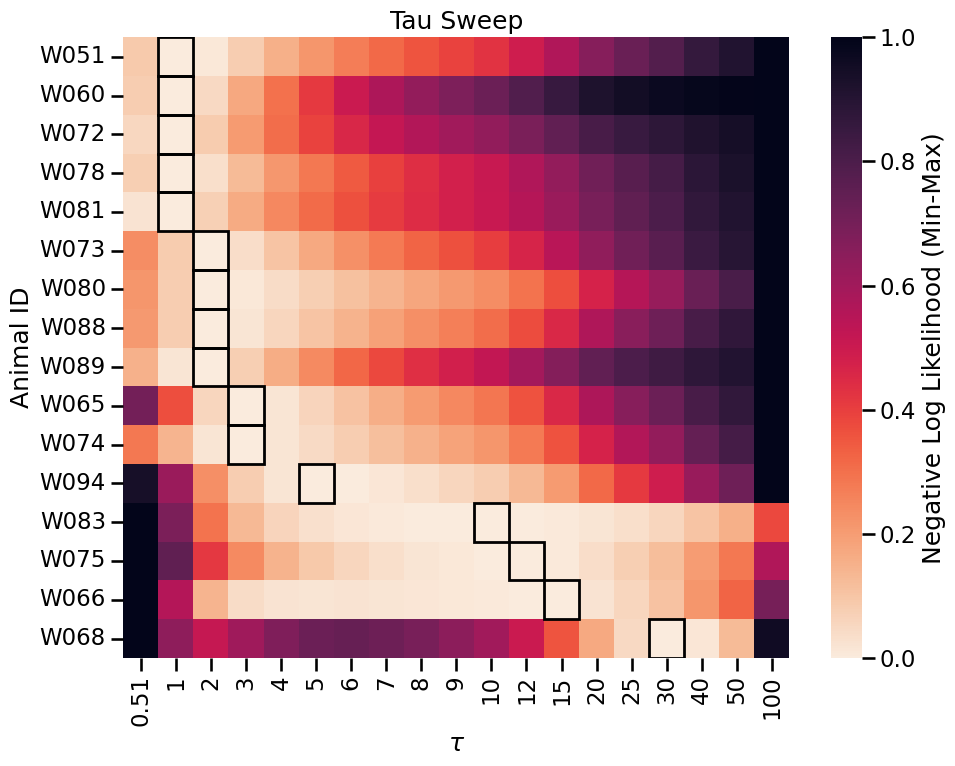

In [32]:

fig, ax = plt.subplots(figsize=(10, 8))
# If you want a Husl palette turned into a colormap:
cmap = sns.color_palette("rocket_r", as_cmap=True)

sns.heatmap(
    pivot_table_nll_minmax,
    ax=ax,
    cmap=cmap,
    cbar_kws={'label': 'Negative Log Likelihood (Min-Max)'}
)

# 3. Draw a pink box around the best‐fit tau for each animal
for animal in pivot_table_nll_minmax.index:
    # find its best tau
    best_tau = best_fit_df.loc[
        best_fit_df['animal_id'] == animal, 
        'best_fit_tau'
    ].values[0]
    # convert tau value to column index
    col = pivot_table_nll_minmax.columns.get_loc(best_tau)
    # convert animal_id to row index
    row = pivot_table_nll_minmax.index.get_loc(animal)
    # create a 1×1 rectangle patch (no fill)
    rect = patches.Rectangle(
        (col, row),      # (x, y) lower-left corner in data coords
        1, 1,            # width, height
        fill=False,
        edgecolor='k',
        lw=2
    )
    ax.add_patch(rect)

ax.set_title("Tau Sweep")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Animal ID")

# Format x-axis labels
ax.set_xticklabels(
    [f"{x:.0f}" if x != 0.51 else f"{x:.2f}" for x in pivot_table_nll_minmax.columns],
    rotation=90,
    ha="center"
)

plt.tight_layout()
plt.show()

fig.savefig("figures/fig3_heatmap_taus.png", dpi=300, bbox_inches="tight")

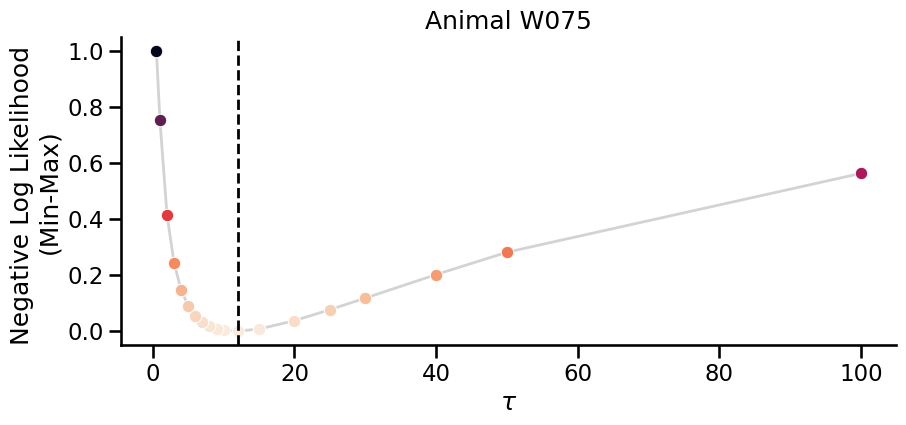

In [33]:
EXAMPLE_ANIMAL = "W075"

nll_df = taus_df.query("animal_id == @EXAMPLE_ANIMAL")

fig, ax = plt.subplots(figsize=(10, 4))
sns.despine()

sns.lineplot(x=nll_df["tau"], y=nll_df["nll_minmax"], ax=ax, linewidth=2, color="lightgray")
sns.lineplot(x=nll_df["tau"], y=nll_df["nll_minmax"], ax=ax, hue=nll_df["nll_minmax"], linewidth=3, marker="o", palette="rocket_r")
ax.axvline(x=nll_df["best_fit_tau"].min(), color="k", linestyle="--", linewidth=2)

ax.legend().remove()
ax.set_title(f"Animal {EXAMPLE_ANIMAL}")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Negative Log Likelihood \n(Min-Max)")

fig.savefig("figures/fig3_example_animal_tau_sweep.png", dpi=300, bbox_inches="tight")

# E- Model Comparison


In [35]:
mvc = ModelVisualizerCompare(load_experiment(compare_exp, save_path=c.MODEL_FITS_PATH))

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_filtered",
]
LABELS = [
    "Baseline",
    "+ Binary\nViolation History",
    "+ Filtered\nViolation History",
]
COLORS = [
    "gray",
    "#93c47d",
    "darkgreen",
]

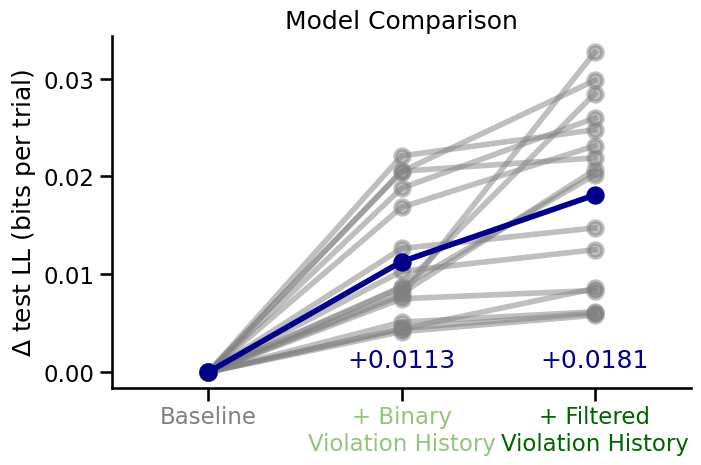

In [36]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
    annotate=True,
    y_annotate=0.0005,
    color_annotate=c.MODEL_COMPARE_COLOR
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)
ax.legend().remove()
ax.set(xlabel="", title="Model Comparison")

# save fig
plt.tight_layout()
plt.savefig("figures/fig3_compare_prev_viol.png", dpi=300, bbox_inches="tight")

In [37]:
bpt = mvc.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])

,mean,std
model_name,,
base,0.000000,0.000000
null,-1.777418,0.070941
prev_viol_binary,0.011287,0.006384
prev_viol_filtered,0.018103,0.009250


## Base vs Binary


In [38]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1046: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1050: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 1256.2841152619944}

> Pooling across animals, the test data are $10^{1256}$ times more likely under the new model than under the base model.


In [39]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

{'geometric_mean_ratio': 3.2942549248705797e+78,
 'log10_geometric_mean_ratio': 78.51775720387464}

> On average, each animal's test data is $1.33 * 10^{78}$ times more likely under the previous violation binary model


## Base vs Filtered


In [40]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1046: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1050: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2184.3332043946034}

> Pooling across animals, the test data are $10^{2184}$ times more likely under the new model than under the base model.


In [41]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

{'geometric_mean_ratio': 3.3176095664555833e+136,
 'log10_geometric_mean_ratio': 136.5208252746627}

> On average, each animal's test data is $3.0 * 10^{136}$ times more likely under the previous violation filtered model
